In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import sys
sys.path.append("../code/libs")
sys.path.append('helpers')
from scipy.stats import pearsonr

In [3]:
%reload_ext autoreload
%autoreload 2

import census as cn
import annotations as ans
import geo
import viz
import twitter
import ios
from constants import SBERT_QUERIES
from constants import NONE

In [4]:
viz.sns_reset()
viz.sns_paper_style()

# Setup

In [5]:
CCODES3 = ['USA', 'CAN']
CCODES2 = ['US', 'CA']

DATA_DIR = '../data/'
RESULTS_DIR = '../results/'
FN_FULL_CORPUS = ios.path_join(RESULTS_DIR, 'full_corpus_2M_merged_tweets_users.pkl')          # ALL
FN_VALID_CORPUS = ios.path_join(RESULTS_DIR, 'valid_corpus_305K_merged_tweets_users.pkl')      # VALID (botomoter + sber)
FN_FINAL_CORPUS = ios.path_join(RESULTS_DIR, 'final_corpus_74K_merged_tweets_users_valid.pkl') # FINAL (botomoter + sber + geo)

FN_DATA = ios.path_join(RESULTS_DIR, "census_twitter_data/<CCODE3>_stats.csv") # file containing census & twitter data per region and year
FN_CENSUS = ios.path_join(DATA_DIR, 'census/<CCODE3>/<CCODE3>_all_census_stats.csv')

ICWSM_RESULTS_DIR = ios.path_join(RESULTS_DIR, 'ICWSM/')
FN_ICWSM_CORPUS = ios.path_join(ICWSM_RESULTS_DIR, 'agg_corpus_twitter_survey_data.pkl')
OUTPUT_DIR = ios.path_join(ICWSM_RESULTS_DIR, 'plots/')

PVALUE = 0.05 
MAX_VAR = 1e-8
DPI = 300
TWITTER_KINDS = ['tweets','users']

In [6]:
significant_results = {kind:{c:cn.pd.DataFrame() for c in CCODES3} for kind in TWITTER_KINDS}
significant_results

{'tweets': {'USA': Empty DataFrame
  Columns: []
  Index: [],
  'CAN': Empty DataFrame
  Columns: []
  Index: []},
 'users': {'USA': Empty DataFrame
  Columns: []
  Index: [],
  'CAN': Empty DataFrame
  Columns: []
  Index: []}}

# All Data

In [7]:
RQ = 'RQ1'

In [8]:
df_merged_final_corpus_valid_tag = ios.read_pickle(FN_FINAL_CORPUS) # tweets with metadata and user metadata worldwide
df_merged_final_corpus_valid_tag.tweet_id.nunique(), df_merged_final_corpus_valid_tag.author_id.nunique()
# (73891, 46366)

(73891, 46366)

In [9]:
df_merged_final_corpus_valid_tag.head(2)

,tweet_id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,...,verified,cap,valid_user,loc_source,ccode_a,geometry_a,lon_a,lat_a,country,year_t
0,1417673516414013440,2766734643,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,...,False,0.278726,True,tweets,US,POINT (-92.13000 34.75000),-92.13,34.75,US,2021
2,1416918506055081985,166379492,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,...,False,0.306188,True,tweets,US,POINT (-68.98000 45.19000),-68.98,45.19,US,2021


In [10]:
gbc = df_merged_final_corpus_valid_tag.groupby('country')
gbc.tweet_id.nunique(), gbc.author_id.nunique()

(country
 CA         4719
 Others    20707
 US        48465
 Name: tweet_id, dtype: int64,
 country
 CA         2497
 Others    13623
 US        30246
 Name: author_id, dtype: int64)

In [11]:
gdf_all = ios.read_pickle(FN_ICWSM_CORPUS) # census_twitter_usa_can
gdf_all.shape
# (442, 273)

(442, 273)

In [12]:
gdf_all.head(2)

,state_name,year,state_code,canpreg_tweets,total_tweets,canpreg_users,total_users,norm_tweets,norm_users,gid,...,regular_healthcare_females_18_to_34_years,regular_healthcare_35_to_49_years,regular_healthcare_males_35_to_49_years,regular_healthcare_females_35_to_49_years,regular_healthcare_50_to_64_years,regular_healthcare_males_50_to_64_years,regular_healthcare_females_50_to_64_years,regular_healthcare_65_years_and_over,regular_healthcare_males_65_years_and_over,regular_healthcare_females_65_years_and_over
0,Alaska,2015,AK,14,831652.0,14,31670.0,0.000017,0.000442,28.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,2016,AK,11,1614422.0,11,50065.0,0.000007,0.000220,28.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


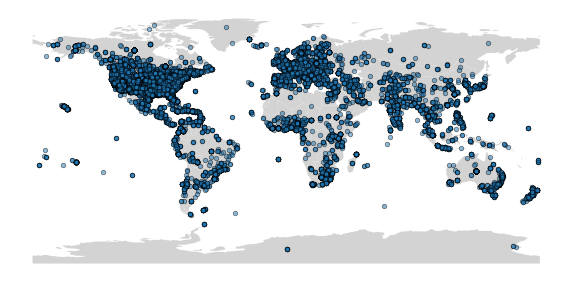

In [13]:
fn = ios.path_join(OUTPUT_DIR, f'{RQ}_worldmap.pdf')
viz.plot_in_map(df_merged_final_corpus_valid_tag.rename(columns={'lon_a':'lon','lat_a':'lat'}), fn=fn)

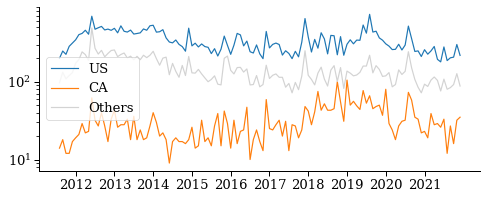

In [14]:
kind = 'author_id'
col_date = 'created_at_t'
fn = ios.path_join(OUTPUT_DIR, f"{RQ}_timeline_{kind.split('_')[0]}.pdf")
viz.plot_timeline(df_merged_final_corpus_valid_tag, 
                  col_date=col_date, col_counts=kind,
                  figsize=(7,3), hue='country', logy=True, fn=fn)

In [15]:
df_merged_final_corpus_valid_tag.groupby('ccode_a').author_id.nunique().sort_values(ascending=False).head(5)
# ccode_a
# US    30246
# GB     3170
# CA     2497
# AU      582
# FR      540

ccode_a
US    30246
GB     3170
CA     2497
AU      582
FR      540
Name: author_id, dtype: int64

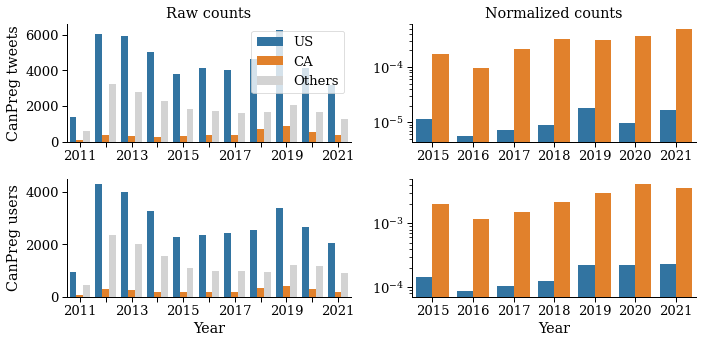

In [16]:
fn = ios.path_join(OUTPUT_DIR, f'{RQ}_counts.pdf')
viz.plot_summary_canpreg_totals(df_merged_final_corpus_valid_tag, fn=fn)

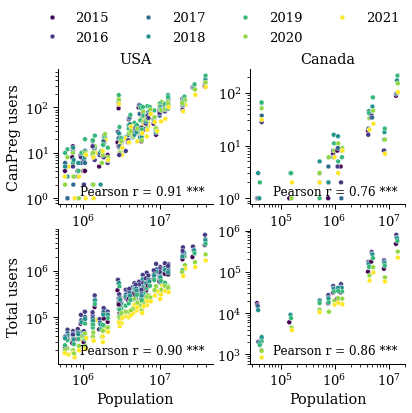

In [17]:
fn = ios.path_join(OUTPUT_DIR, f'RQ2_corr_size.pdf')
viz.plot_corr_size(gdf_all, fn=fn)

# Data per Country

In [18]:
cid = 0
ccode3 = CCODES3[cid]
ccode2 = CCODES2[cid]

fn_data = FN_DATA.replace('<CCODE3>',ccode3)
if not ios.exists(fn_data):
    data = cn.create_twitter_census_data_file(ccode3, fn_data, FN_CENSUS)
else:
    data = ios.read_csv(fn_data)

data = data.reset_index()
data.shape
# (373, 48)

(373, 48)

In [19]:
data.head(5)

,state_name,state_code,year,canpreg_tweets,total_tweets,canpreg_users,total_users,norm_tweets,norm_users,geometry,...,years_50_to_54,years_55_to_59,years_5_to_9,years_60_to_64,years_65_to_69,years_70_to_74,years_75_to_79,years_80_to_84,years_85_and_above,years_under_5
0,Alabama,AL,2015,30,4063618,29,252536,0.000007,0.000115,"POLYGON ((-88.1399880001326 34.5817030002605, ...",...,7.1,6.8,6.3,6.2,5.0,3.6,2.7,1.9,1.7,6.1
1,Alabama,AL,2016,36,10029024,34,413550,0.000004,0.000082,"POLYGON ((-88.1399880001326 34.5817030002605, ...",...,7.1,6.9,6.3,6.1,5.2,3.8,2.7,1.9,1.7,6.0
2,Alabama,AL,2017,40,7477896,34,345845,0.000005,0.000098,"POLYGON ((-88.1399880001326 34.5817030002605, ...",...,337003.0,332906.0,303938.0,303593.0,257700.0,191137.0,136137.0,94089.0,82969.0,292163.0
3,Alabama,AL,2018,33,7265007,30,328765,0.000005,0.000091,"POLYGON ((-88.1399880001326 34.5817030002605, ...",...,330762.0,334011.0,302174.0,309004.0,263099.0,199958.0,141180.0,96159.0,83436.0,292125.0
4,Alabama,AL,2019,40,6449554,37,267036,0.000006,0.000139,"POLYGON ((-88.1399880001326 34.5817030002605, ...",...,323104.0,333209.0,301064.0,315793.0,267037.0,209644.0,145096.0,98755.0,84349.0,293187.0


In [20]:
tmp = df_merged_final_corpus_valid_tag.query("country==@ccode2")
tmp.tweet_id.nunique(), tmp.author_id.nunique()
# (48465, 30246)

(48465, 30246)

# Plots

In [21]:
viz.sns_reset()
viz.sns_paper_style()

## Basic

In [22]:
RQ = 'RQ1'

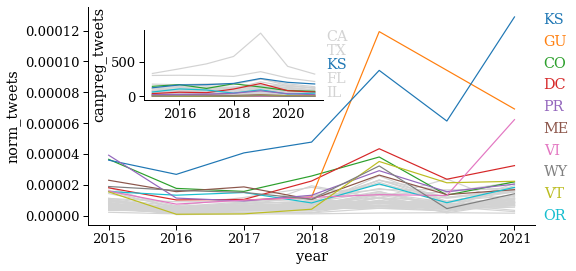

In [23]:
kind = 'tweets'

fn = ios.path_join(OUTPUT_DIR, f'{RQ}_{ccode3}_{kind}_per_state_year.pdf')
viz.plot_data_per_year(data, y='norm_tweets', topk=10, hue='state_code', yin='canpreg_tweets', figsize=(8,4), logy=ccode2=='CA', fn=fn)

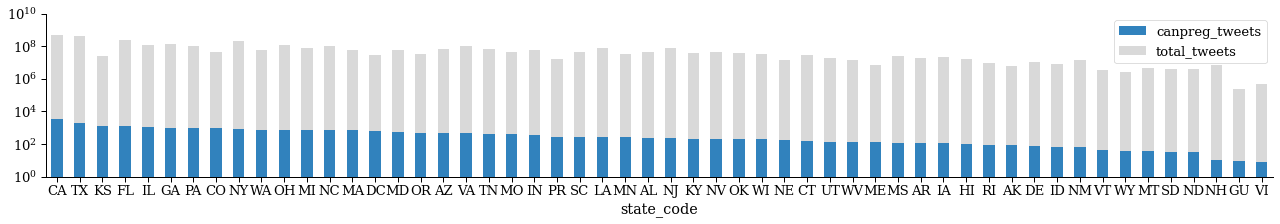

In [24]:
kind = 'tweets'
fn = ios.path_join(OUTPUT_DIR, f'{RQ}_{ccode3}_{kind}_per_state.pdf')
viz.plot_count_per_state(data, source=kind, country=ccode3, fn=fn)

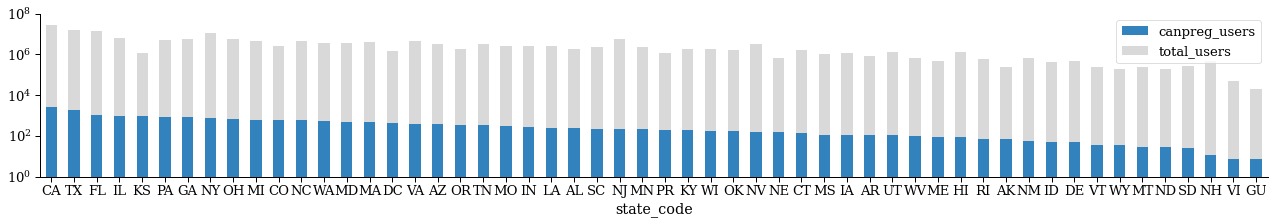

In [25]:
kind = 'users'
fn = ios.path_join(OUTPUT_DIR, f'{RQ}_{ccode3}_{kind}_per_state.pdf')
viz.plot_count_per_state(data, source=kind, country=ccode3, fn=fn)

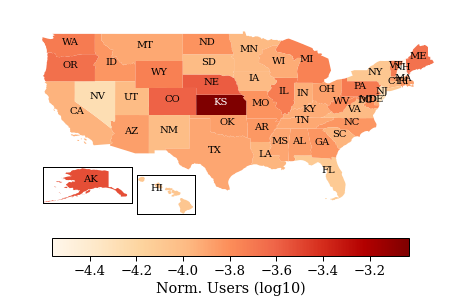

In [26]:
fn = ios.path_join(OUTPUT_DIR, f'{RQ}_{ccode3}.pdf')
gdf_usa = gdf_all.query("country==@ccode3 and state_code not in ['PR','VI','GU']").copy()
cn.plot_map_twitter_data(gdf_usa, kind='users', title=None, figsize=(8,8), area_name=True, shrink=0.8, dpi=DPI, fn=fn, white_states=['KS'], log=True)

## Correlations

In [27]:
RQ = 'RQ2'

In [28]:
keys = ['state_name','state_code','year']
groups = set([c.split('_')[0] for c in data.columns if c not in ['state_name','state_code','year','geometry'] and 'tweet' not in c and 'user' not in c])
groups

{'abortions',
 'births',
 'deaths',
 'drug',
 'fertility',
 'insurance',
 'pop',
 'population',
 'poverty',
 'years'}

2015 norm_users norm_population_females 7.582856279434112e-09 6.297008100548073e-05
[-44.60705671   0.51211219]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_population_females.pdf saved!


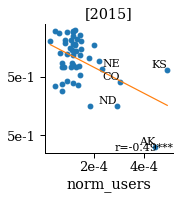

2016 norm_users norm_population_females 4.771276225947327e-09 6.152564233964413e-05
[-34.27331662   0.50871557]
../results/ICWSM/plots/RQ2_USA_2016_norm_users_vs_norm_population_females.pdf saved!


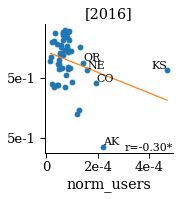

2018 norm_users norm_population_females 9.955180019274412e-09 6.215601724745267e-05
[-28.24771656   0.50903955]
../results/ICWSM/plots/RQ2_USA_2018_norm_users_vs_norm_population_females.pdf saved!


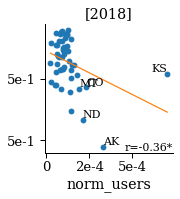

2015 norm_users norm_population_males 7.582856279434112e-09 6.297008100548066e-05
[44.60705671  0.48788781]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_population_males.pdf saved!


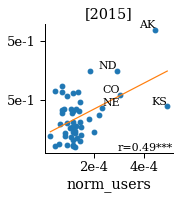

2016 norm_users norm_population_males 4.771276225947327e-09 6.152564233964407e-05
[34.27331662  0.49128443]
../results/ICWSM/plots/RQ2_USA_2016_norm_users_vs_norm_population_males.pdf saved!


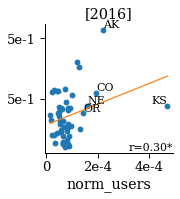

2018 norm_users norm_population_males 9.955180019274412e-09 6.215601724745271e-05
[28.24771656  0.49096045]
../results/ICWSM/plots/RQ2_USA_2018_norm_users_vs_norm_population_males.pdf saved!


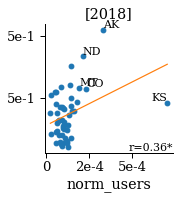

2015 norm_users norm_years_10_to_14 7.582856279434112e-09 7.272650602975842e-12
[1.08549297e-02 1.13890266e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_10_to_14.pdf saved!


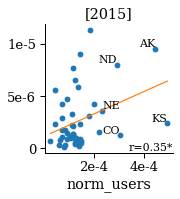

2015 norm_users norm_years_15_to_19 7.582856279434112e-09 8.49199383173487e-12
[1.10711851e-02 1.23817978e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_15_to_19.pdf saved!


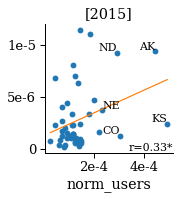

2015 norm_users norm_years_20_to_24 7.582856279434112e-09 1.1349169155506907e-11
[1.41058252e-02 1.09876467e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_20_to_24.pdf saved!


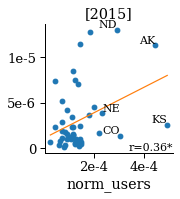

2018 norm_users norm_years_20_to_24 9.955180019274412e-09 2.351940509007642e-05
[15.75987337  0.06759847]
../results/ICWSM/plots/RQ2_USA_2018_norm_users_vs_norm_years_20_to_24.pdf saved!


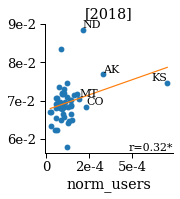

2015 norm_users norm_years_25_to_29 7.582856279434112e-09 8.974557083950954e-12
[1.29836402e-02 9.95283861e-07]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_25_to_29.pdf saved!


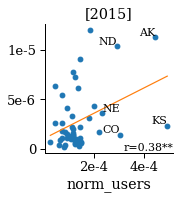

2015 norm_users norm_years_30_to_34 7.582856279434112e-09 8.081720660616567e-12
[1.16897425e-02 1.09138430e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_30_to_34.pdf saved!


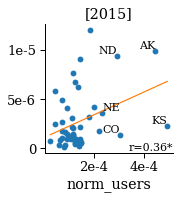

2015 norm_users norm_years_35_to_39 7.582856279434112e-09 6.372478049536065e-12
[9.93980325e-03 1.09712153e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_35_to_39.pdf saved!


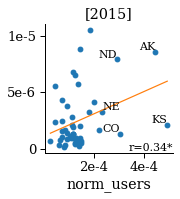

2015 norm_users norm_years_40_to_44 7.582856279434112e-09 6.465055972219499e-12
[9.51477131e-03 1.21130343e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_40_to_44.pdf saved!


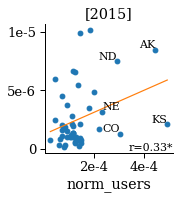

2015 norm_users norm_years_45_to_49 7.582856279434112e-09 7.540368410433114e-12
[9.94258325e-03 1.28836312e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_45_to_49.pdf saved!


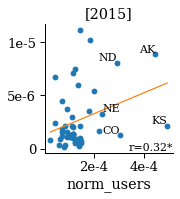

2018 norm_users norm_years_45_to_49 9.955180019274412e-09 1.727949129229095e-05
[-13.6770674   0.0646039]
../results/ICWSM/plots/RQ2_USA_2018_norm_users_vs_norm_years_45_to_49.pdf saved!


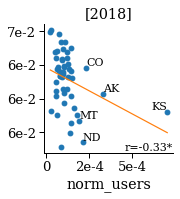

2015 norm_users norm_years_50_to_54 7.582856279434112e-09 1.0137153110273617e-11
[1.17283012e-02 1.34481895e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_50_to_54.pdf saved!


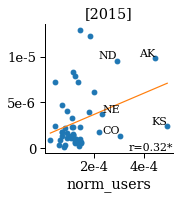

2015 norm_users norm_years_55_to_59 7.582856279434112e-09 1.0129919143199637e-11
[1.16536681e-02 1.28056284e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_55_to_59.pdf saved!


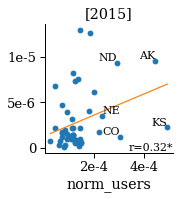

2015 norm_users norm_years_5_to_9 7.582856279434112e-09 7.569304389457897e-12
[1.13470206e-02 1.09016608e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_5_to_9.pdf saved!


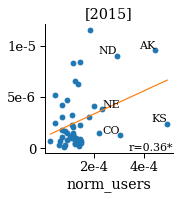

2015 norm_users norm_years_60_to_64 7.582856279434112e-09 7.776854742197754e-12
[9.59696413e-03 1.23068989e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_60_to_64.pdf saved!


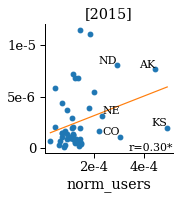

2015 norm_users norm_years_under_5 7.582856279434112e-09 7.706890850698779e-12
[1.20737731e-02 9.43682490e-07]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_years_under_5.pdf saved!


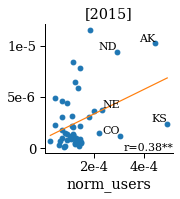

2015 norm_users norm_pop_females_reproductive 7.582856279434112e-09 3.733922939865119e-10
[7.67160933e-02 7.91226810e-06]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_norm_pop_females_reproductive.pdf saved!


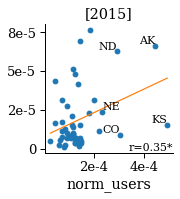

2015 norm_users fertility_rate 7.582856279434112e-09 40.71714102457308
[23245.46064261    60.70292509]
../results/ICWSM/plots/RQ2_USA_2015_norm_users_vs_fertility_rate.pdf saved!


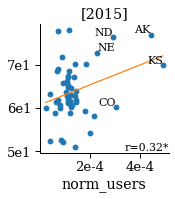

2016 norm_users norm_insurance_public 4.771276225947327e-09 2.6099533415292266e-09
[-0.22412878  0.00036824]
../results/ICWSM/plots/RQ2_USA_2016_norm_users_vs_norm_insurance_public.pdf saved!


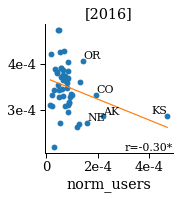

2016 norm_users norm_drug_deaths 4.771276225947327e-09 3.12073492076684e-08
[-7.31402627e-01  4.82705801e-04]
../results/ICWSM/plots/RQ2_USA_2016_norm_users_vs_norm_drug_deaths.pdf saved!


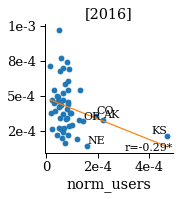

2018 norm_users norm_drug_deaths 9.955180019274412e-09 3.686218977289337e-08
[-5.43477061e-01  5.05231175e-04]
../results/ICWSM/plots/RQ2_USA_2018_norm_users_vs_norm_drug_deaths.pdf saved!


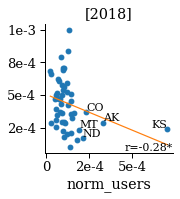

In [29]:
kind = TWITTER_KINDS[1]
x = f"norm_{kind}"
col_pop = 'population'
topk = 5
polydeg = 1
outliers_state_codes = []
hide_y = True

summary = cn.compute_and_plot_correlations(data, groups, kind, x, col_pop, topk, polydeg, outliers_state_codes, hide_y, PVALUE, ccode3, RQ, OUTPUT_DIR)

In [30]:
significant_results[kind][ccode3] = summary.sort_values(['year','rabs','p'], ascending=[False, False, True]).copy()
significant_results[kind][ccode3]

,group,year,x,y,x_var,y_var,r,rabs,p
2,population,2018,norm_users,norm_population_females,9.955180e-09,6.215602e-05,-0.357492,0.357492,0.010811
5,population,2018,norm_users,norm_population_males,9.955180e-09,6.215602e-05,0.357492,0.357492,0.010811
15,years,2018,norm_users,norm_years_45_to_49,9.955180e-09,1.727949e-05,-0.328286,0.328286,0.019937
9,years,2018,norm_users,norm_years_20_to_24,9.955180e-09,2.351941e-05,0.324238,0.324238,0.021609
25,drug,2018,norm_users,norm_drug_deaths,9.955180e-09,3.686219e-08,-0.282433,0.282433,0.046894
23,insurance,2016,norm_users,norm_insurance_public,4.771276e-09,2.609953e-09,-0.303039,0.303039,0.032420
1,population,2016,norm_users,norm_population_females,4.771276e-09,6.152564e-05,-0.301818,0.301818,0.033159
4,population,2016,norm_users,norm_population_males,4.771276e-09,6.152564e-05,0.301818,0.301818,0.033159
24,drug,2016,norm_users,norm_drug_deaths,4.771276e-09,3.120735e-08,-0.285986,0.285986,0.044078
0,population,2015,norm_users,norm_population_females,7.582856e-09,6.297008e-05,-0.489500,0.489500,0.000358


In [31]:
significant_results[kind][ccode3].query("year==2020 and y in ['norm_pop_females_reproductive','norm_well_mental_health'] ")

,group,year,x,y,x_var,y_var,r,rabs,p


In [32]:
best_results = significant_results[kind][ccode3].query("x_var < @MAX_VAR").reset_index(drop=True)

In [33]:
best_results

,group,year,x,y,x_var,y_var,r,rabs,p
0,population,2018,norm_users,norm_population_females,9.955180e-09,6.215602e-05,-0.357492,0.357492,0.010811
1,population,2018,norm_users,norm_population_males,9.955180e-09,6.215602e-05,0.357492,0.357492,0.010811
2,years,2018,norm_users,norm_years_45_to_49,9.955180e-09,1.727949e-05,-0.328286,0.328286,0.019937
3,years,2018,norm_users,norm_years_20_to_24,9.955180e-09,2.351941e-05,0.324238,0.324238,0.021609
4,drug,2018,norm_users,norm_drug_deaths,9.955180e-09,3.686219e-08,-0.282433,0.282433,0.046894
5,insurance,2016,norm_users,norm_insurance_public,4.771276e-09,2.609953e-09,-0.303039,0.303039,0.032420
6,population,2016,norm_users,norm_population_females,4.771276e-09,6.152564e-05,-0.301818,0.301818,0.033159
7,population,2016,norm_users,norm_population_males,4.771276e-09,6.152564e-05,0.301818,0.301818,0.033159
8,drug,2016,norm_users,norm_drug_deaths,4.771276e-09,3.120735e-08,-0.285986,0.285986,0.044078
9,population,2015,norm_users,norm_population_females,7.582856e-09,6.297008e-05,-0.489500,0.489500,0.000358


In [34]:
print(best_results[['year','y','r','p']].set_index(['year','y']).round(2).to_latex())

\begin{tabular}{llrr}
\toprule
     &                     &     r &     p \\
year & y &       &       \\
\midrule
2018 & norm\_population\_females & -0.36 &  0.01 \\
     & norm\_population\_males &  0.36 &  0.01 \\
     & norm\_years\_45\_to\_49 & -0.33 &  0.02 \\
     & norm\_years\_20\_to\_24 &  0.32 &  0.02 \\
     & norm\_drug\_deaths & -0.28 &  0.05 \\
2016 & norm\_insurance\_public & -0.30 &  0.03 \\
     & norm\_population\_females & -0.30 &  0.03 \\
     & norm\_population\_males &  0.30 &  0.03 \\
     & norm\_drug\_deaths & -0.29 &  0.04 \\
2015 & norm\_population\_females & -0.49 &  0.00 \\
     & norm\_population\_males &  0.49 &  0.00 \\
     & norm\_years\_under\_5 &  0.38 &  0.01 \\
     & norm\_years\_25\_to\_29 &  0.38 &  0.01 \\
     & norm\_years\_20\_to\_24 &  0.36 &  0.01 \\
     & norm\_years\_5\_to\_9 &  0.36 &  0.01 \\
     & norm\_years\_30\_to\_34 &  0.36 &  0.01 \\
     & norm\_years\_10\_to\_14 &  0.35 &  0.01 \\
     & norm\_pop\_females\_reproductive &  0

In [35]:
ccode3, kind

('USA', 'users')

In [38]:
significant_results[kind][ccode3].sort_values('rabs', ascending=False).query("x_var < @MAX_VAR").head(6)

,group,year,x,y,x_var,y_var,r,rabs,p
0,population,2015,norm_users,norm_population_females,7.582856e-09,6.297008e-05,-0.489500,0.489500,0.000358
3,population,2015,norm_users,norm_population_males,7.582856e-09,6.297008e-05,0.489500,0.489500,0.000358
20,years,2015,norm_users,norm_years_under_5,7.582856e-09,7.706891e-12,0.378721,0.378721,0.007288
10,years,2015,norm_users,norm_years_25_to_29,7.582856e-09,8.974557e-12,0.377404,0.377404,0.007511
8,years,2015,norm_users,norm_years_20_to_24,7.582856e-09,1.134917e-11,0.364614,0.364614,0.010002
18,years,2015,norm_users,norm_years_5_to_9,7.582856e-09,7.569304e-12,0.359145,0.359145,0.011267


In [39]:
t = 0 
cc = 'USA'
for _,tmp in gdf_all.query("country==@cc").groupby('state_name').total_tweets.sum().sort_values(ascending=False).reset_index().iterrows():
    v =  (tmp.total_tweets*100)/gdf_all.query("country==@cc").total_tweets.sum()
    print(tmp.state_name, tmp.total_tweets,v)
    t+=v
t

# Kansas 25417502.0 0.768750283561236
# Northwest Territories 162408.0 0.10677774441429838

California 489231405.0 14.796764108479735
Texas 402165244.0 12.163455140614277
Florida 230082354.0 6.958822109266941
New York 206851179.0 6.25619710824557
Georgia 139471482.0 4.218303645110595
Ohio 125055539.0 3.7822946199494036
Illinois 112922532.0 3.415332808686422
Pennsylvania 107772046.0 3.259556777942796
Virginia 97362250.0 2.944713343414312
North Carolina 97238468.0 2.940969566877979
Michigan 81730985.0 2.4719470030724944
New Jersey 76357358.0 2.309422090907549
Louisiana 73213159.0 2.2143260475267734
Arizona 67368892.0 2.0375666667875656
Tennessee 63439169.0 1.9187125138276442
Massachusetts 61822644.0 1.869820846498029
Washington 61555541.0 1.861742337957337
Maryland 59267304.0 1.7925347957446793
Indiana 57911370.0 1.7515246820446657
Nevada 46449131.0 1.404850194461399
Missouri 44172041.0 1.3359797923583736
South Carolina 43710437.0 1.3220186168702
Alabama 43700098.0 1.3217059146549415
Colorado 41230915.0 1.247025675368855
Kentucky 37747782.0 1.1416786006865554
Oklahoma 37658139.

100.00000000000001